In [ ]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent          # notebooks/ -> project root
sys.path.insert(0, str(ROOT / "src"))
from evaluation.catalogue import Catalogue
from evaluation.paths import Paths

cat = Catalogue(Paths(ROOT))
print(cat.report())

import os

import numpy as np

from evaluation.catalogue import Catalogue
from evaluation.engine import rollout
from evaluation.engine.types import IDENTITY
from evaluation.manipulators.delay import delay
from evaluation.paths import Paths
from evaluation.settings import DEFAULT

ROOT = os.path.abspath(os.path.join(".."))
paths = Paths(ROOT)
cat = Catalogue(paths)  

Catalogue: 15 runs in 9 groups
  dual_64+64u                       interleaved  dual 128u split0.5  seeds=[42, 43, 44, 45, 46] (n=5)
  dual_64+64u                       unperturbed  dual 128u split0.5  seeds=[42] (n=1)
  dual_64+64u_equal_delays          interleaved  dual 128u split0.5  seeds=[42] (n=1)
  dual_64+64u_reversed_delays       interleaved  dual 128u split0.5  seeds=[42] (n=1)
  dual_64+64u_velocity_penalty_0    interleaved  dual 128u split0.5  seeds=[42] (n=1)
  mono_128u                         interleaved  mono 128u split0.5  seeds=[42] (n=1)
  mono_128u                         unperturbed  mono 128u split0.5  seeds=[42] (n=1)
  mono_64u                          interleaved  mono 64u split0.5  seeds=[42, 43, 44] (n=3)
  mono_64u_velocity_penalty_0.02    interleaved  mono 64u split0.5  seeds=[42] (n=1)


In [4]:
import numpy as np

from evaluation import analyzers as A
from evaluation.engine import rollout

rec = cat.canonical("dual").record(42)
comp = rollout(rec, Paths(ROOT), task="reach", duration_s=None, batch_size=32)   # competence
trem = rollout(rec, Paths(ROOT), task="reach", duration_s=6.0, batch_size=32)     # tremor window
print("reach:", {k: float(v.mean()) for k, v in A.reach_metrics(comp).items()})
print("osc:",   {k: float(np.nanmean(v)) for k, v in A.oscillation_metrics(trem).items()})
print("tremor:", float(np.nanmean(A.tremor_metrics(trem)["intention_index"])))

Locked seed: 42
Locked seed: 42
reach: {'terminal_error_cm': 0.4191324898891308, 'peak_speed_cms': 47.571308274054104, 'path_efficiency': 0.8780375873314312, 'muscle_effort': 18.527959026381836}
osc: {'hold_speed_rms_cms': 0.41634554527613826, 'freq_lateral_hz': 0.21787848605577687, 'freq_resolution_hz': 0.199203187250996}
tremor: 0.0968018582713329


In [3]:
from evaluation.engine.types import BASELINE_COMPETENCE, BASELINE_HOLD
from evaluation.orchestrate import run_specs
from evaluation.settings import DEFAULT
from evaluation.store import aggregate_seeds, load_atoms

rec = cat.canonical("dual").record(42)
atoms = run_specs(rec, Paths(ROOT), [BASELINE_COMPETENCE, BASELINE_HOLD], DEFAULT)

# read them straight back as a tidy DataFrame — the store's job
df = load_atoms(Paths(ROOT).results / "metrics")
print(df[["model", "seed", "variant", "metric", "mean", "std", "n_trials"]].to_string(index=False))

Locked seed: 42
[atom] dual_64+64u seed42 · baseline_competence -> /Users/ana_radu/dissertation_clean/results/metrics/dual_64+64u/interleaved_training/20260708_0006_seed42/baseline_competence/metrics.json
Locked seed: 42
[atom] dual_64+64u seed42 · baseline_hold -> /Users/ana_radu/dissertation_clean/results/metrics/dual_64+64u/interleaved_training/20260708_0006_seed42/baseline_hold/metrics.json
      model  seed             variant             metric      mean          std  n_trials
dual_64+64u    42 baseline_competence  terminal_error_cm  0.489108 1.810979e-01       256
dual_64+64u    42 baseline_competence     peak_speed_cms 45.350869 1.108931e+01       256
dual_64+64u    42 baseline_competence    path_efficiency  0.888543 5.347147e-02       256
dual_64+64u    42 baseline_competence      muscle_effort 18.420455 4.886980e-01       256
dual_64+64u    42       baseline_hold hold_speed_rms_cms  0.385347 1.347726e-01       256
dual_64+64u    42       baseline_hold    freq_lateral_hz  0.20

In [4]:
from evaluation.orchestrate import run_group

run_group(cat.canonical("dual"), Paths(ROOT), BASELINE_COMPETENCE, DEFAULT)
agg = aggregate_seeds(load_atoms(Paths(ROOT).results / "metrics"))
print(agg[agg.variant == "baseline_competence"].to_string(index=False))

Locked seed: 42
[atom] dual_64+64u seed42 · baseline_competence -> /Users/ana_radu/dissertation_clean/results/metrics/dual_64+64u/interleaved_training/20260708_0006_seed42/baseline_competence/metrics.json
Locked seed: 42
[atom] dual_64+64u seed43 · baseline_competence -> /Users/ana_radu/dissertation_clean/results/metrics/dual_64+64u/interleaved_training/20260726_2354_seed43/baseline_competence/metrics.json
Locked seed: 42
[atom] dual_64+64u seed44 · baseline_competence -> /Users/ana_radu/dissertation_clean/results/metrics/dual_64+64u/interleaved_training/20260727_1008_seed44/baseline_competence/metrics.json
Locked seed: 42
[atom] dual_64+64u seed45 · baseline_competence -> /Users/ana_radu/dissertation_clean/results/metrics/dual_64+64u/interleaved_training/20260729_1521_seed45/baseline_competence/metrics.json
Locked seed: 42
[atom] dual_64+64u seed46 · baseline_competence -> /Users/ana_radu/dissertation_clean/results/metrics/dual_64+64u/interleaved_training/20260728_1234_seed46/baseline

In [5]:
df = load_atoms(Paths(ROOT).results / "metrics")
mask = (df.model == "dual_64+64u") & (df.seed == 42) & (df.variant == "baseline_competence")
print(df[mask][["seed", "metric", "mean", "n_trials"]].to_string(index=False))

 seed            metric      mean  n_trials
   42 terminal_error_cm  0.489108       256
   42    peak_speed_cms 45.350869       256
   42   path_efficiency  0.888543       256
   42     muscle_effort 18.420455       256


In [2]:
from evaluation.engine import obs_layout
from evaluation.engine.types import VariantSpec
from evaluation.manipulators import ablate, delay
from evaluation.orchestrate import run_variant
from evaluation.settings import DEFAULT

rec = cat.canonical("dual").record(42)

# 1) a big delay injection — expect hold-RMS to rise vs the intact baseline (0.39 cm/s)
spec = VariantSpec(name="delay_both_+150ms", intervention=delay(150, channel="both"),
                   task="reach", profile="tremor", metrics="hold")
atom = run_variant(rec, Paths(ROOT), spec, DEFAULT)
print("delayed hold-RMS:", atom.metrics["hold_speed_rms_cms"])

# 2) proprioceptive ablation — expect terminal error to blow up vs 0.34 cm (your §2.1 ~25 cm)
layout = obs_layout(rec)
spec_abl = VariantSpec(name="ablate_prop", intervention=ablate("prop", layout),
                       task="reach", profile="competence", metrics="competence")
atom_abl = run_variant(rec, Paths(ROOT), spec_abl, DEFAULT)
print("prop-ablated terminal error:", atom_abl.metrics["terminal_error_cm"])

Locked seed: 42
[atom] dual_64+64u seed42 · delay_both_+150ms -> /Users/ana_radu/dissertation_clean/results/metrics/dual_64+64u/interleaved_training/20260708_0006_seed42/delay_both_+150ms/metrics.json
delayed hold-RMS: {'mean': 269.55354599427494, 'std': 98.5691300997276, 'n': 256}
Locked seed: 42
[atom] dual_64+64u seed42 · ablate_prop -> /Users/ana_radu/dissertation_clean/results/metrics/dual_64+64u/interleaved_training/20260708_0006_seed42/ablate_prop/metrics.json
prop-ablated terminal error: {'mean': 25.746545000303243, 'std': 15.117272404363085, 'n': 256}


In [2]:
from evaluation.sweep import delay_sweep

sweep = delay_sweep(cat.canonical("dual").record(42), Paths(ROOT), channel="both")
for d, r in zip(sweep.added_ms, sweep.hold_rms_cms):
    print(f"  +{d:3.0f} ms   hold-RMS {r:8.2f} cm/s {'  <-- oscillating' if r >= sweep.threshold_cms else ''}")
print(f"\nΔc (dual, seed 42) = {sweep.delta_c_ms:.0f} ms")

Locked seed: 42
[atom] dual_64+64u seed42 · baseline_hold -> /Users/ana_radu/dissertation_clean/results/metrics/dual_64+64u/interleaved_training/20260708_0006_seed42/baseline_hold/metrics.json
Locked seed: 42
[atom] dual_64+64u seed42 · delay_both_+20ms -> /Users/ana_radu/dissertation_clean/results/metrics/dual_64+64u/interleaved_training/20260708_0006_seed42/delay_both_+20ms/metrics.json
Locked seed: 42
[atom] dual_64+64u seed42 · delay_both_+40ms -> /Users/ana_radu/dissertation_clean/results/metrics/dual_64+64u/interleaved_training/20260708_0006_seed42/delay_both_+40ms/metrics.json
Locked seed: 42
[atom] dual_64+64u seed42 · delay_both_+60ms -> /Users/ana_radu/dissertation_clean/results/metrics/dual_64+64u/interleaved_training/20260708_0006_seed42/delay_both_+60ms/metrics.json
Locked seed: 42
[atom] dual_64+64u seed42 · delay_both_+80ms -> /Users/ana_radu/dissertation_clean/results/metrics/dual_64+64u/interleaved_training/20260708_0006_seed42/delay_both_+80ms/metrics.json
Locked seed

In [3]:
from evaluation.sweep import delay_sweep_group
import numpy as np
sweeps = delay_sweep_group(cat.canonical("dual"), Paths(ROOT), channel="both")
dcs = np.array([s.delta_c_ms for s in sweeps])
print(f"dual Δc = {np.nanmean(dcs):.0f} ± {np.nanstd(dcs, ddof=1):.0f} ms  (n={np.isfinite(dcs).sum()} seeds)")

Locked seed: 42
[atom] dual_64+64u seed42 · baseline_hold -> /Users/ana_radu/dissertation_clean/results/metrics/dual_64+64u/interleaved_training/20260708_0006_seed42/baseline_hold/metrics.json
Locked seed: 42
[atom] dual_64+64u seed42 · delay_both_+20ms -> /Users/ana_radu/dissertation_clean/results/metrics/dual_64+64u/interleaved_training/20260708_0006_seed42/delay_both_+20ms/metrics.json
Locked seed: 42
[atom] dual_64+64u seed42 · delay_both_+40ms -> /Users/ana_radu/dissertation_clean/results/metrics/dual_64+64u/interleaved_training/20260708_0006_seed42/delay_both_+40ms/metrics.json
Locked seed: 42
[atom] dual_64+64u seed42 · delay_both_+60ms -> /Users/ana_radu/dissertation_clean/results/metrics/dual_64+64u/interleaved_training/20260708_0006_seed42/delay_both_+60ms/metrics.json
Locked seed: 42
[atom] dual_64+64u seed42 · delay_both_+80ms -> /Users/ana_radu/dissertation_clean/results/metrics/dual_64+64u/interleaved_training/20260708_0006_seed42/delay_both_+80ms/metrics.json
Locked seed

In [4]:
for s in sweeps:
    print(f"\n{s.model} seed {s.seed}:  Δc = {s.delta_c_ms:.0f} ms")
    for d, r in zip(s.added_ms, s.hold_rms_cms):
        flag = "  <-- OSC" if r >= s.threshold_cms else ""
        print(f"    +{d:3.0f} ms   {r:8.2f} cm/s{flag}")


dual_64+64u seed 42:  Δc = 87 ms
    +  0 ms       0.39 cm/s
    + 20 ms       0.52 cm/s
    + 40 ms       1.06 cm/s
    + 60 ms       2.50 cm/s
    + 80 ms       5.58 cm/s
    +100 ms      17.60 cm/s  <-- OSC
    +120 ms     149.64 cm/s  <-- OSC
    +150 ms     269.55 cm/s  <-- OSC
    +200 ms     320.57 cm/s  <-- OSC

dual_64+64u seed 43:  Δc = 43 ms
    +  0 ms       0.55 cm/s
    + 20 ms       0.64 cm/s
    + 40 ms       2.73 cm/s
    + 60 ms      53.30 cm/s  <-- OSC
    + 80 ms     247.00 cm/s  <-- OSC
    +100 ms     294.87 cm/s  <-- OSC
    +120 ms     324.83 cm/s  <-- OSC
    +150 ms     345.52 cm/s  <-- OSC
    +200 ms     385.81 cm/s  <-- OSC

dual_64+64u seed 44:  Δc = 23 ms
    +  0 ms       0.33 cm/s
    + 20 ms       1.78 cm/s
    + 40 ms      62.92 cm/s  <-- OSC
    + 60 ms     248.21 cm/s  <-- OSC
    + 80 ms     299.20 cm/s  <-- OSC
    +100 ms     329.41 cm/s  <-- OSC
    +120 ms     348.98 cm/s  <-- OSC
    +150 ms     361.94 cm/s  <-- OSC
    +200 ms     363.11 cm/

In [5]:
fine = (0, 10, 20, 30, 40, 50, 60, 70, 80, 100, 120, 150)
sweeps = delay_sweep_group(cat.canonical("dual"), Paths(ROOT), channel="both", grid_ms=fine)
for s in sweeps:
    print(f"{s.model} seed {s.seed}: Δc = {s.delta_c_ms:.0f} ms")
dcs = np.array([s.delta_c_ms for s in sweeps])
print(f"dual Δc = {np.nanmean(dcs):.0f} ± {np.nanstd(dcs, ddof=1):.0f} ms (n={np.isfinite(dcs).sum()})")

Locked seed: 42
[atom] dual_64+64u seed42 · baseline_hold -> /Users/ana_radu/dissertation_clean/results/metrics/dual_64+64u/interleaved_training/20260708_0006_seed42/baseline_hold/metrics.json
Locked seed: 42
[atom] dual_64+64u seed42 · delay_both_+10ms -> /Users/ana_radu/dissertation_clean/results/metrics/dual_64+64u/interleaved_training/20260708_0006_seed42/delay_both_+10ms/metrics.json
Locked seed: 42
[atom] dual_64+64u seed42 · delay_both_+20ms -> /Users/ana_radu/dissertation_clean/results/metrics/dual_64+64u/interleaved_training/20260708_0006_seed42/delay_both_+20ms/metrics.json
Locked seed: 42
[atom] dual_64+64u seed42 · delay_both_+30ms -> /Users/ana_radu/dissertation_clean/results/metrics/dual_64+64u/interleaved_training/20260708_0006_seed42/delay_both_+30ms/metrics.json
Locked seed: 42
[atom] dual_64+64u seed42 · delay_both_+40ms -> /Users/ana_radu/dissertation_clean/results/metrics/dual_64+64u/interleaved_training/20260708_0006_seed42/delay_both_+40ms/metrics.json
Locked seed

In [6]:
for s in sweeps:
    print(f"\n{s.model} seed {s.seed}:  Δc = {s.delta_c_ms:.0f} ms")
    for d, r in zip(s.added_ms, s.hold_rms_cms):
        flag = "  <-- OSC" if r >= s.threshold_cms else ""
        print(f"    +{d:3.0f} ms   {r:8.2f} cm/s{flag}")


dual_64+64u seed 42:  Δc = 87 ms
    +  0 ms       0.39 cm/s
    + 10 ms       0.43 cm/s
    + 20 ms       0.52 cm/s
    + 30 ms       0.71 cm/s
    + 40 ms       1.06 cm/s
    + 50 ms       1.67 cm/s
    + 60 ms       2.50 cm/s
    + 70 ms       3.70 cm/s
    + 80 ms       5.58 cm/s
    +100 ms      17.60 cm/s  <-- OSC
    +120 ms     149.64 cm/s  <-- OSC
    +150 ms     269.55 cm/s  <-- OSC

dual_64+64u seed 43:  Δc = 50 ms
    +  0 ms       0.55 cm/s
    + 10 ms       0.56 cm/s
    + 20 ms       0.64 cm/s
    + 30 ms       1.09 cm/s
    + 40 ms       2.73 cm/s
    + 50 ms       8.10 cm/s
    + 60 ms      53.30 cm/s  <-- OSC
    + 70 ms     196.48 cm/s  <-- OSC
    + 80 ms     247.00 cm/s  <-- OSC
    +100 ms     294.87 cm/s  <-- OSC
    +120 ms     324.83 cm/s  <-- OSC
    +150 ms     345.52 cm/s  <-- OSC

dual_64+64u seed 44:  Δc = 30 ms
    +  0 ms       0.33 cm/s
    + 10 ms       0.55 cm/s
    + 20 ms       1.78 cm/s
    + 30 ms       8.16 cm/s
    + 40 ms      62.92 cm/s  <-- 

Locked seed: 42


/var/folders/1l/kswlft0x7fl5gcf6b1l__gxc0000gn/T/ipykernel_41173/3376649470.py:18: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(Paths(ROOT).results / f"_scratch_hold_s{rec.seed}_+{d}.png", dpi=110)
/Users/ana_radu/micromamba/envs/motor_control/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


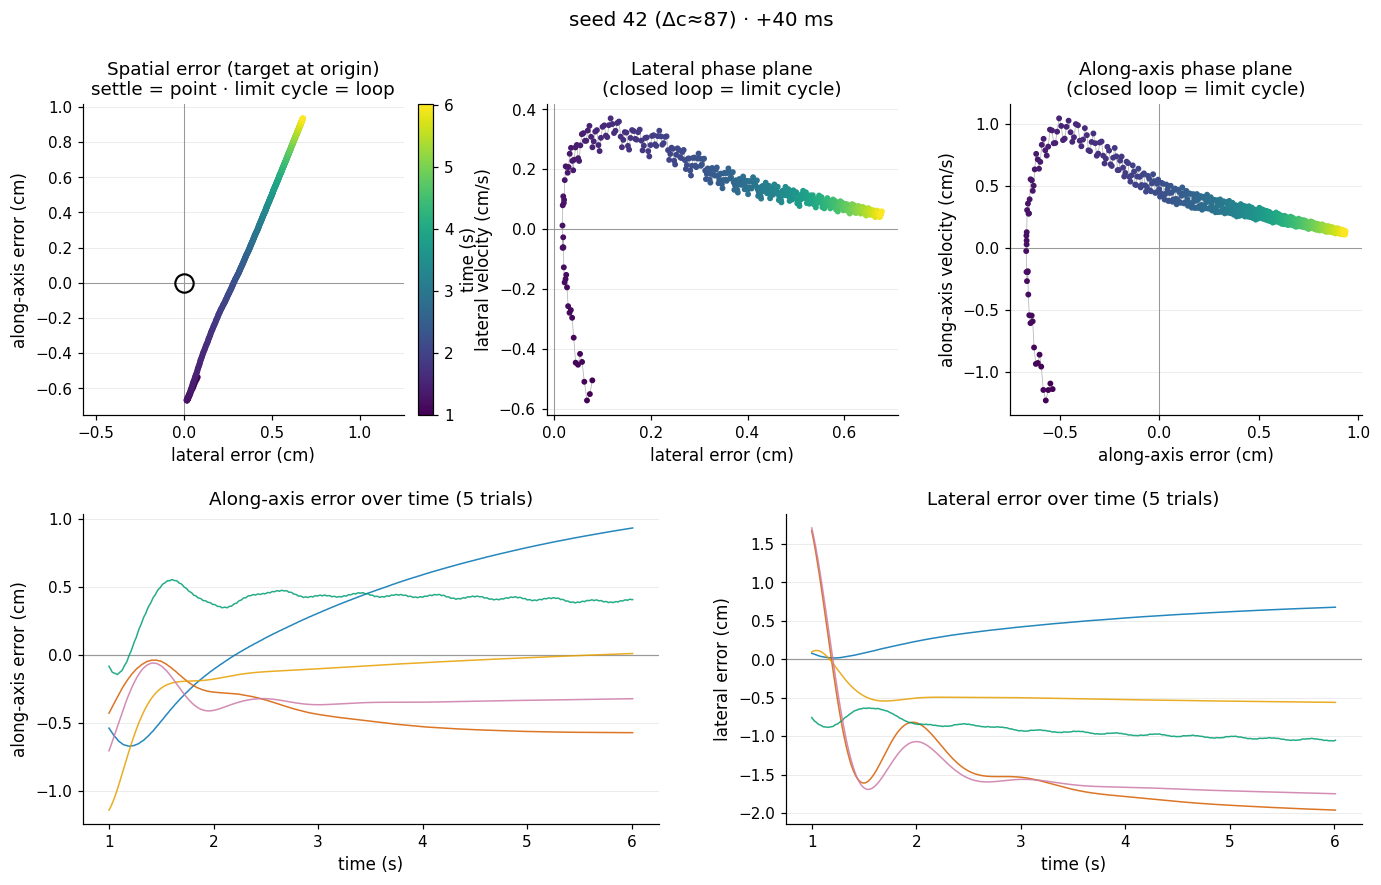

Locked seed: 42


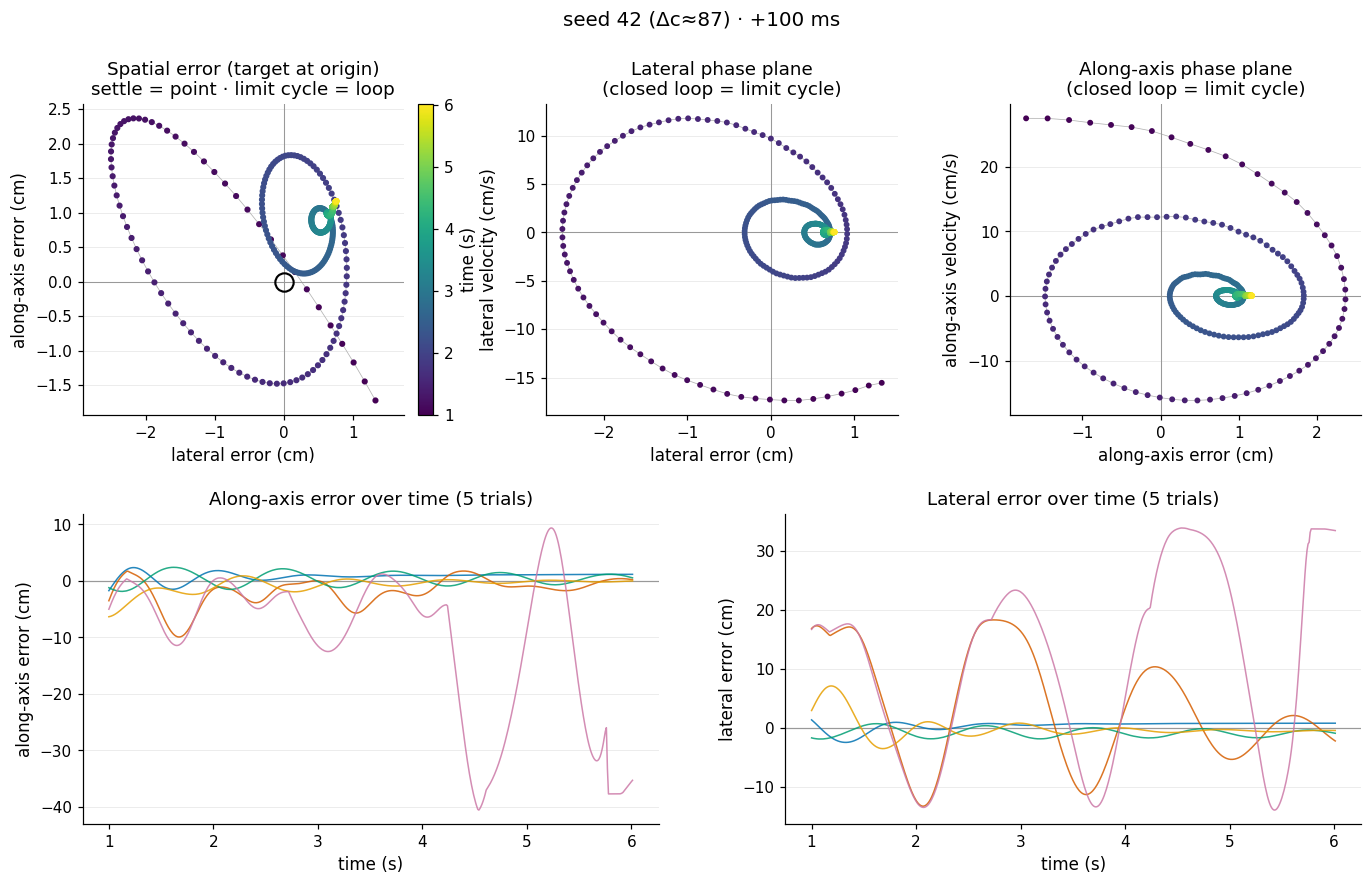

Locked seed: 42


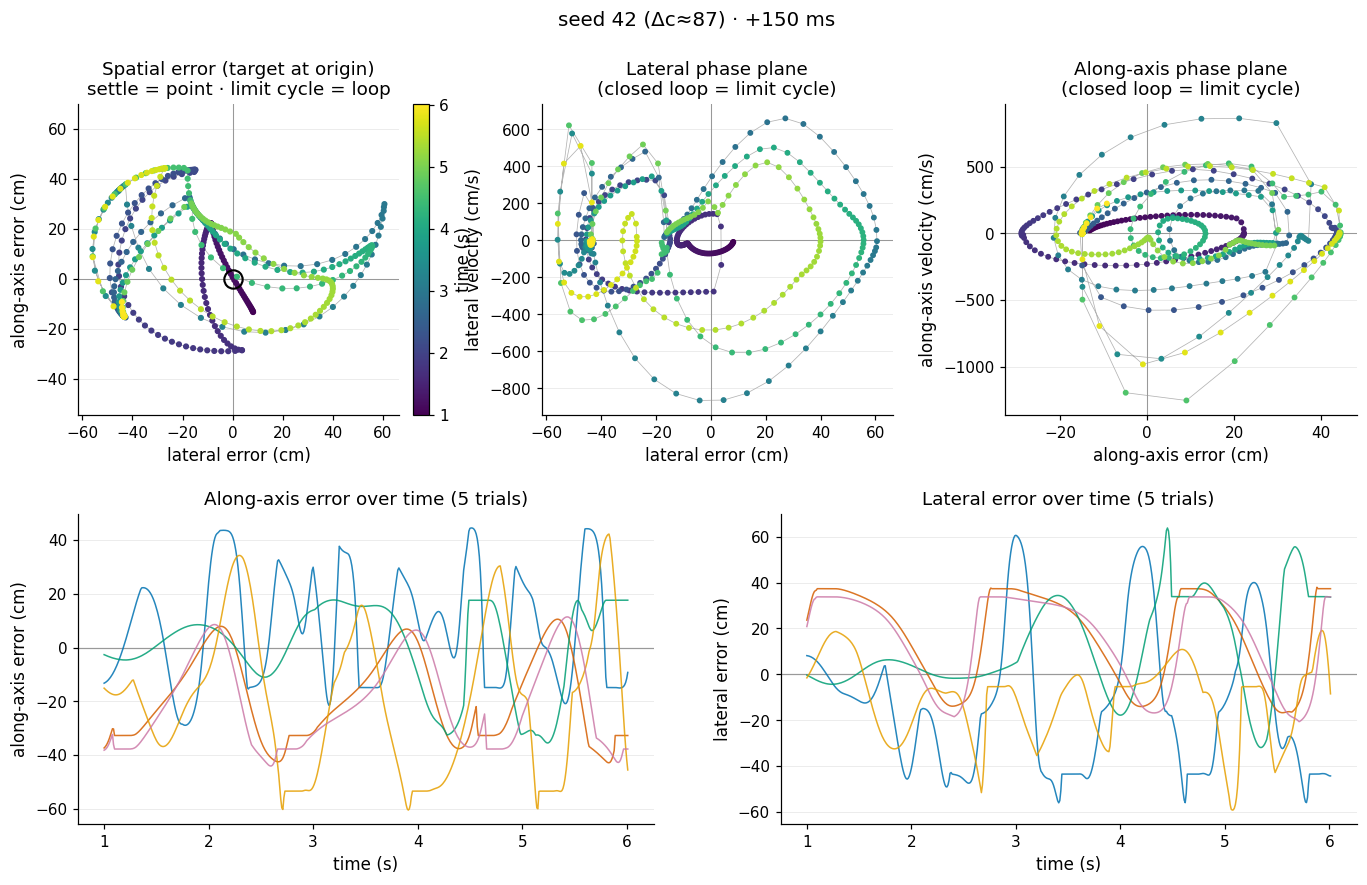

Locked seed: 42


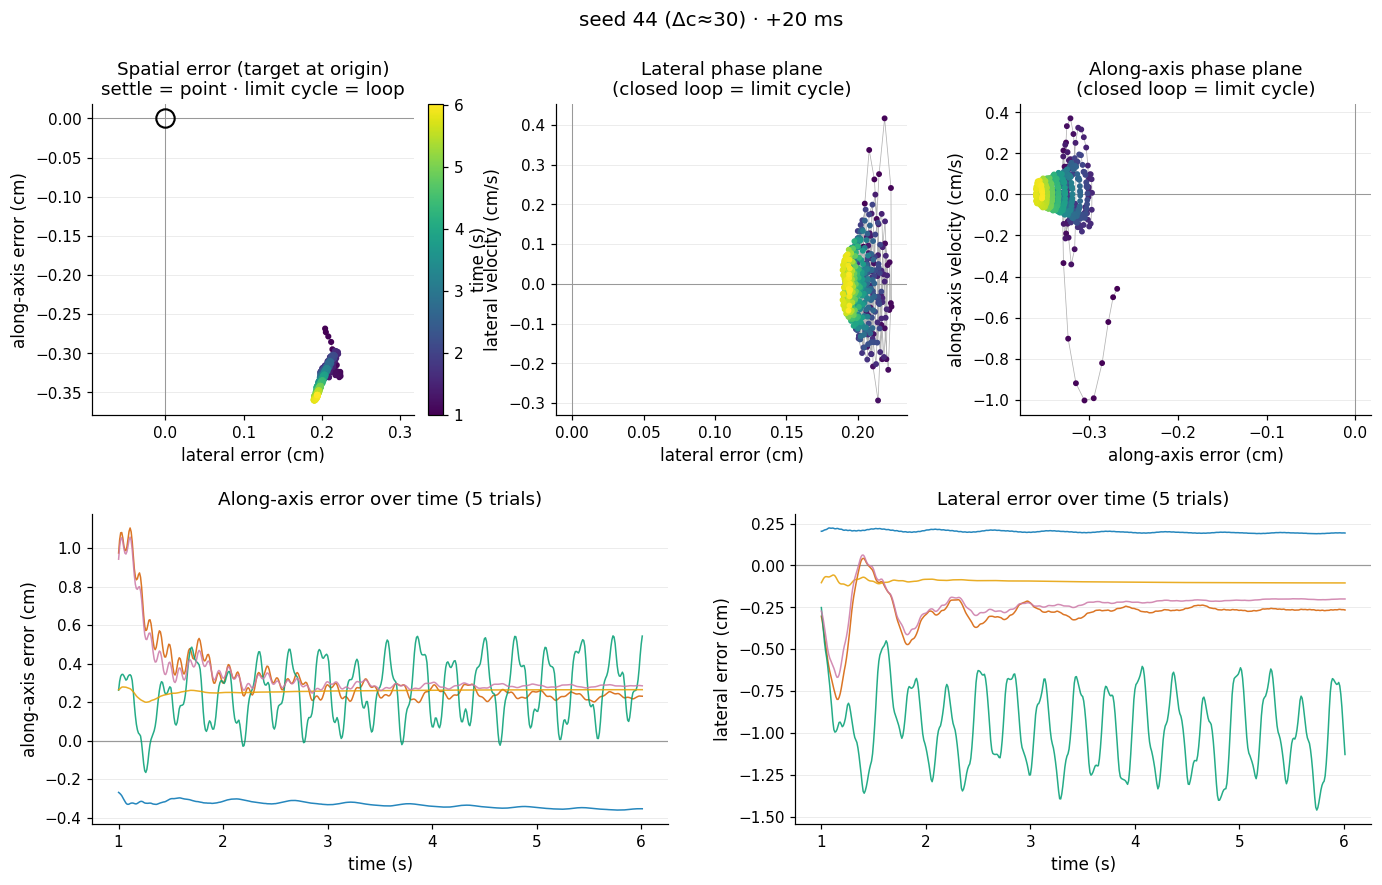

Locked seed: 42


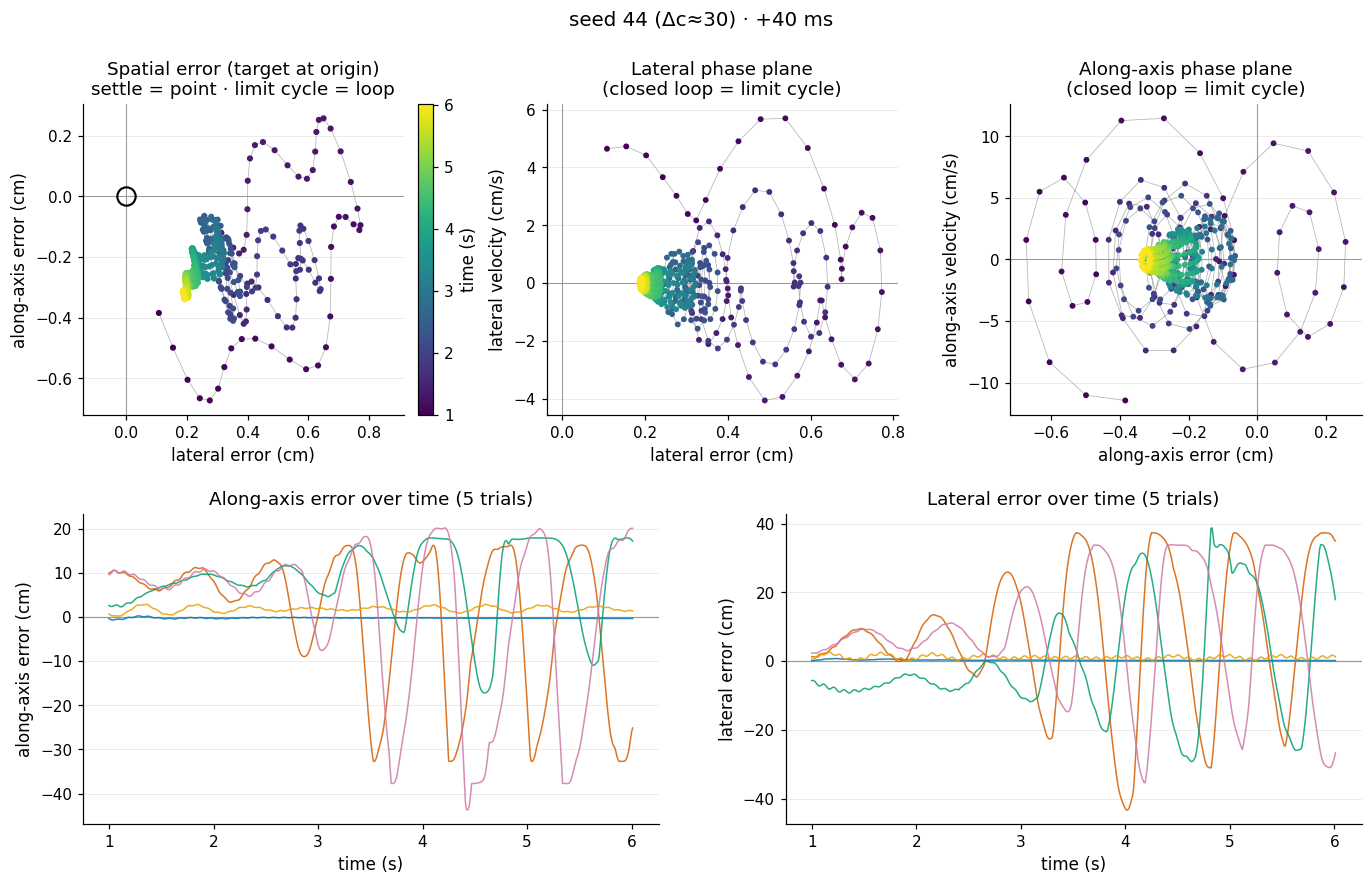

Locked seed: 42


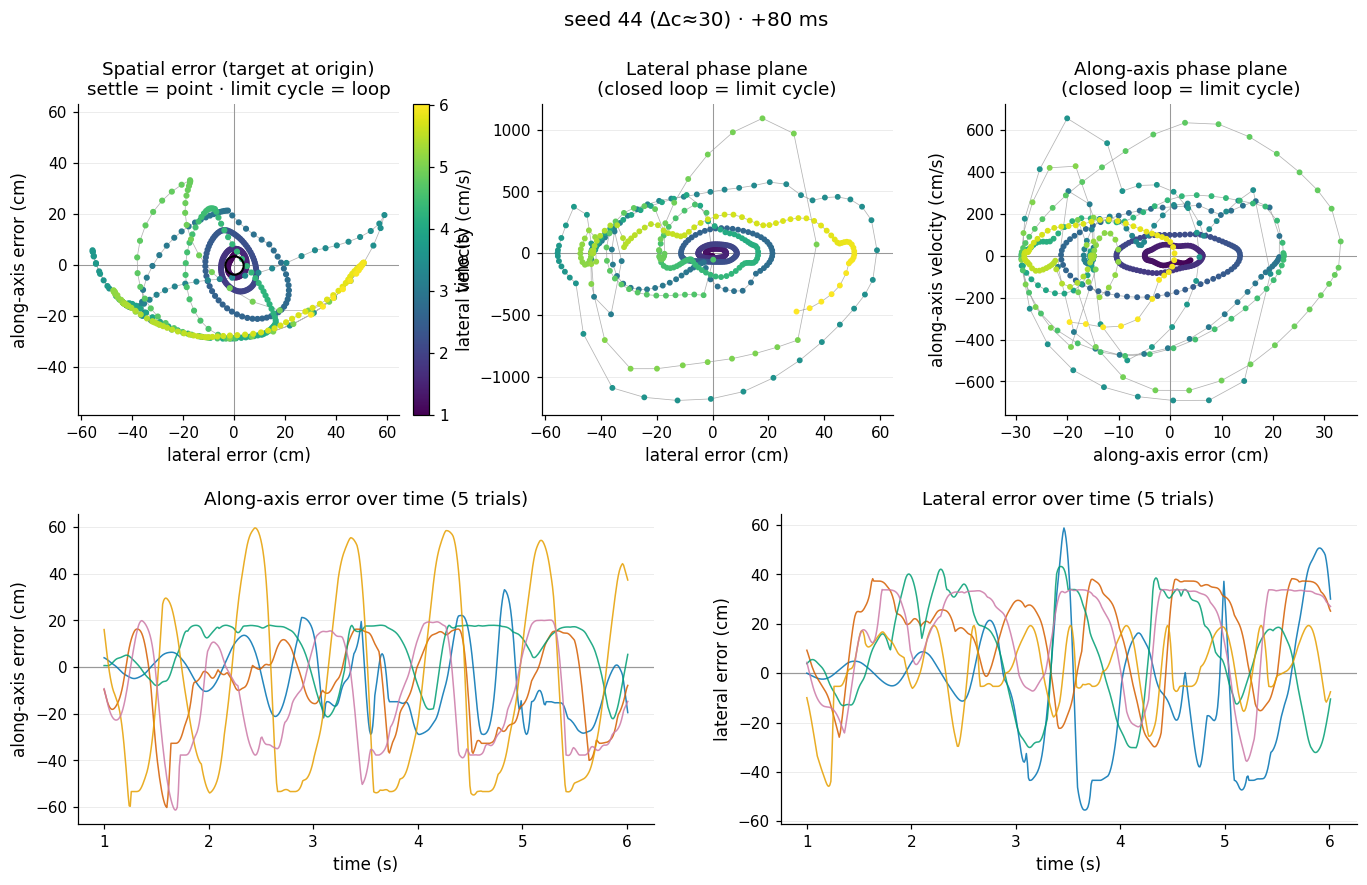

In [ ]:
import matplotlib.pyplot as plt

from evaluation.engine import rollout
from evaluation.figures import apply_style, plot_hold_dynamics, save_figure
from evaluation.manipulators.delay import delay

apply_style()

rec42 = cat.canonical("dual").record(42)   # graceful, Δc≈87
rec44 = cat.canonical("dual").record(44)   # steep,    Δc≈30

for rec, dc, deltas in [(rec42, 87, [40, 100, 150]), (rec44, 30, [20, 40, 80])]:
    bp, bv = rec.config.proprioception_delay, rec.config.vision_delay
    for d in deltas:
        iv = delay(d, mode="additive_both", base_prop_ms=bp, base_vision_ms=bv)
        res = rollout(rec, Paths(ROOT), task="reach", duration_s=6.0, batch_size=32, intervention=iv)
        fig = plot_hold_dynamics(res, title=f"seed {rec.seed} (Δc≈{dc}) · +{d} ms")
        fig.savefig(Paths(ROOT).results / f"_scratch_hold_s{rec.seed}_+{d}.png", dpi=110)
        plt.show()



Locked seed: 42
[fig] dual_64+64u s42 · delay_additive_both_+0ms/hold_dynamics.png -> /Users/ana_radu/dissertation_clean/results/figures/dual_64+64u/interleaved_training/20260708_0006_seed42/delay_additive_both_+0ms/hold_dynamics


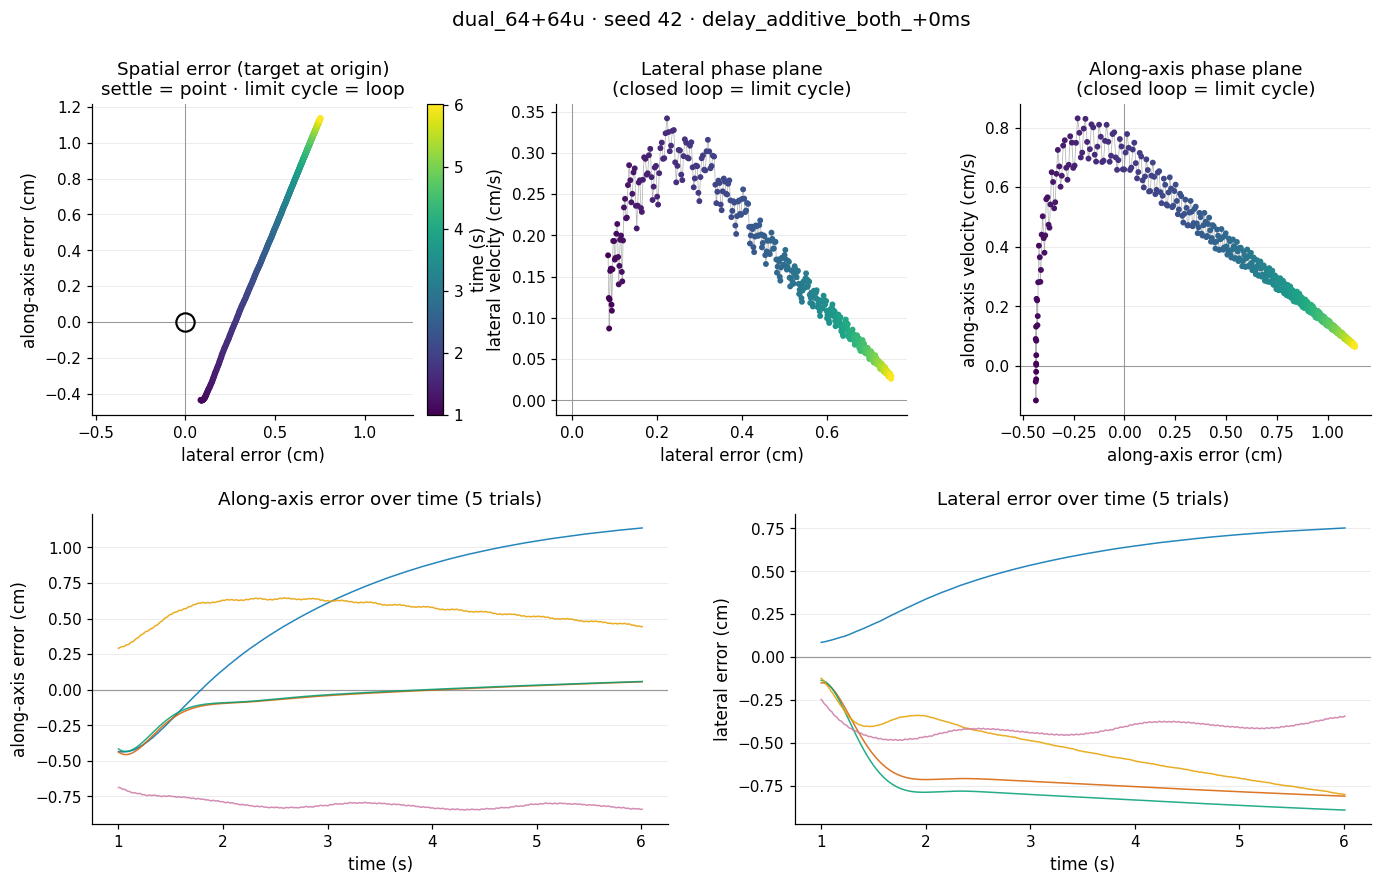

Locked seed: 42
[fig] dual_64+64u s42 · delay_additive_both_+0ms/hold_trajectory_3d.png -> /Users/ana_radu/dissertation_clean/results/figures/dual_64+64u/interleaved_training/20260708_0006_seed42/delay_additive_both_+0ms/hold_trajectory_3d


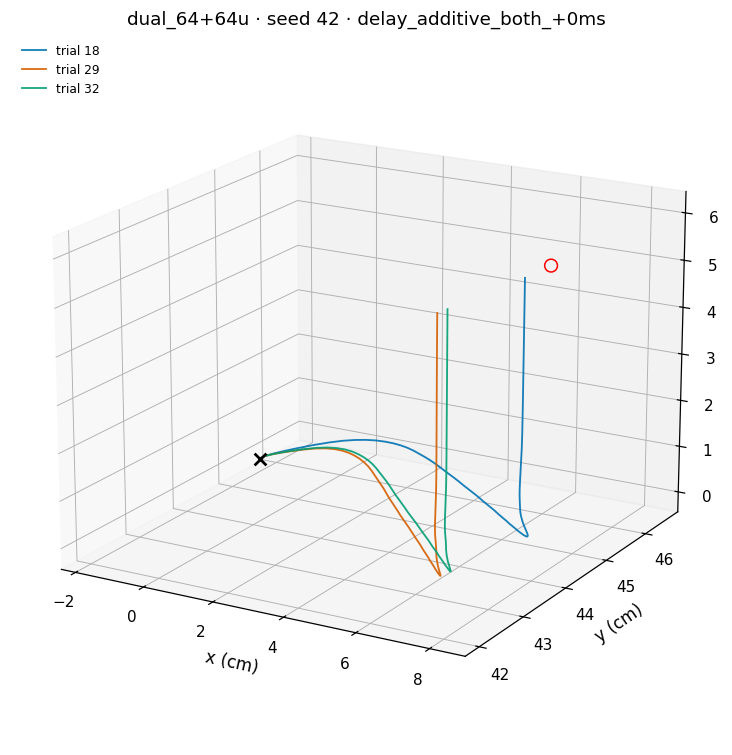

Locked seed: 42
[fig] dual_64+64u s42 · delay_additive_both_+0ms/hold_dynamics.png -> /Users/ana_radu/dissertation_clean/results/figures/dual_64+64u/interleaved_training/20260708_0006_seed42/delay_additive_both_+0ms/hold_dynamics
Locked seed: 42
[fig] dual_64+64u s43 · delay_additive_both_+0ms/hold_dynamics.png -> /Users/ana_radu/dissertation_clean/results/figures/dual_64+64u/interleaved_training/20260726_2354_seed43/delay_additive_both_+0ms/hold_dynamics
Locked seed: 42
[fig] dual_64+64u s44 · delay_additive_both_+0ms/hold_dynamics.png -> /Users/ana_radu/dissertation_clean/results/figures/dual_64+64u/interleaved_training/20260727_1008_seed44/delay_additive_both_+0ms/hold_dynamics
Locked seed: 42
[fig] dual_64+64u s45 · delay_additive_both_+0ms/hold_dynamics.png -> /Users/ana_radu/dissertation_clean/results/figures/dual_64+64u/interleaved_training/20260729_1521_seed45/delay_additive_both_+0ms/hold_dynamics
Locked seed: 42
[fig] dual_64+64u s46 · delay_additive_both_+0ms/hold_dynamics.p

[<Figure size 1650x935 with 6 Axes>,
 <Figure size 1650x935 with 6 Axes>,
 <Figure size 1650x935 with 6 Axes>,
 <Figure size 1650x935 with 6 Axes>,
 <Figure size 1650x935 with 6 Axes>]

In [ ]:
from evaluation.engine.types import VariantSpec
from evaluation.figures import (
    FigureSpec,
    plot_hold_dynamics,
    plot_hold_trajectory_3d,
    render_figure,
    render_group,
)
from evaluation.manipulators.delay import delay

added_delay_ms = 0

def delay_variant(rec, added_ms, mode="additive_both"):
    bp, bv = rec.config.proprioception_delay, rec.config.vision_delay
    iv = delay(added_ms, mode=mode, base_prop_ms=bp, base_vision_ms=bv)
    return VariantSpec(name=f"delay_{mode}_+{added_ms:g}ms", intervention=iv,
                       task="reach", profile="tremor", metrics="hold")

rec = cat.canonical("dual").record(42)
hold_fig = FigureSpec("hold_dynamics", plot_hold_dynamics, kwargs={})
render_figure(rec, Paths(ROOT), delay_variant(rec, added_delay_ms), hold_fig)     

# 3-D appendix, one call:
traj3d = FigureSpec("hold_trajectory_3d", plot_hold_trajectory_3d, kwargs={"direction": 0})
render_figure(rec, Paths(ROOT), delay_variant(rec, added_delay_ms), traj3d)

# across all 5 dual seeds, each to its own folder — no overwrites:
render_group(cat.canonical("dual"), Paths(ROOT), delay_variant(rec, added_delay_ms), hold_fig, show=False)

In [2]:
from evaluation.figures import (
    FigureSpec,
    plot_hold_dynamics,
    plot_hold_trajectory_3d,
    render_delay_series,
)

figs = [FigureSpec("hold_dynamics", plot_hold_dynamics, kwargs={}),
        FigureSpec("hold_trajectory_3d", plot_hold_trajectory_3d, kwargs={"direction": 0})]

# dual seed 42 across below/at/above its Δc≈50; mono seed 42 across its Δc≈10
render_delay_series(cat.canonical("dual"), Paths(ROOT), figs, deltas_ms=(20, 50, 100), seeds=[42])
render_delay_series(cat.canonical("mono"), Paths(ROOT), figs, deltas_ms=(0, 10, 40), seeds=[42])

Locked seed: 42


/Users/ana_radu/dissertation_clean/src/evaluation/figures/style.py:87: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(path.with_suffix(f".{fmt}"))


Locked seed: 42
Locked seed: 42
[batch] rendered 6 figures
Locked seed: 42
Locked seed: 42
Locked seed: 42
[batch] rendered 6 figures


6

[fig] money plot -> /Users/ana_radu/dissertation_clean/results/aggregated/delay/F5_money_plot.png


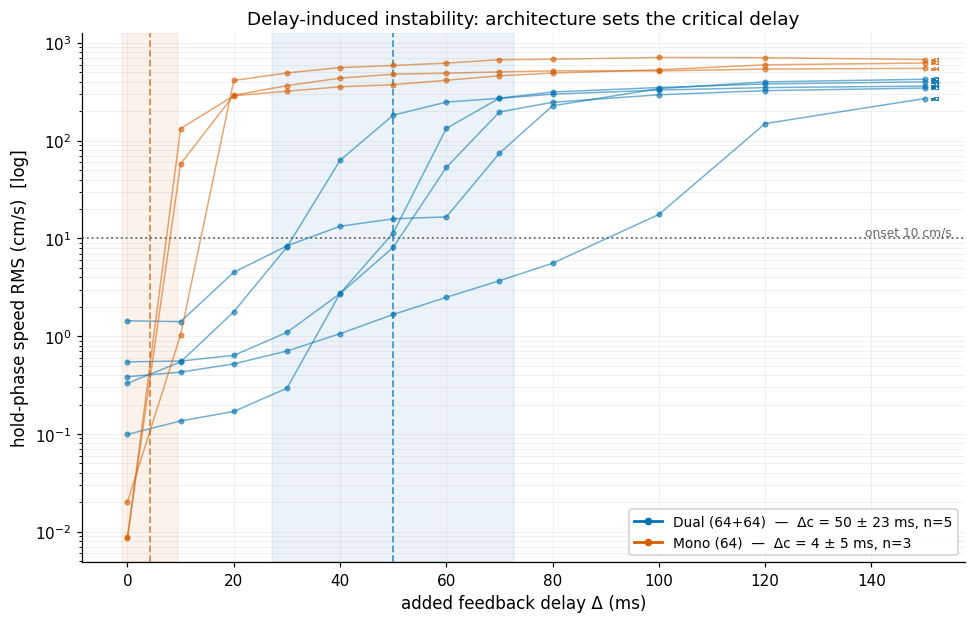

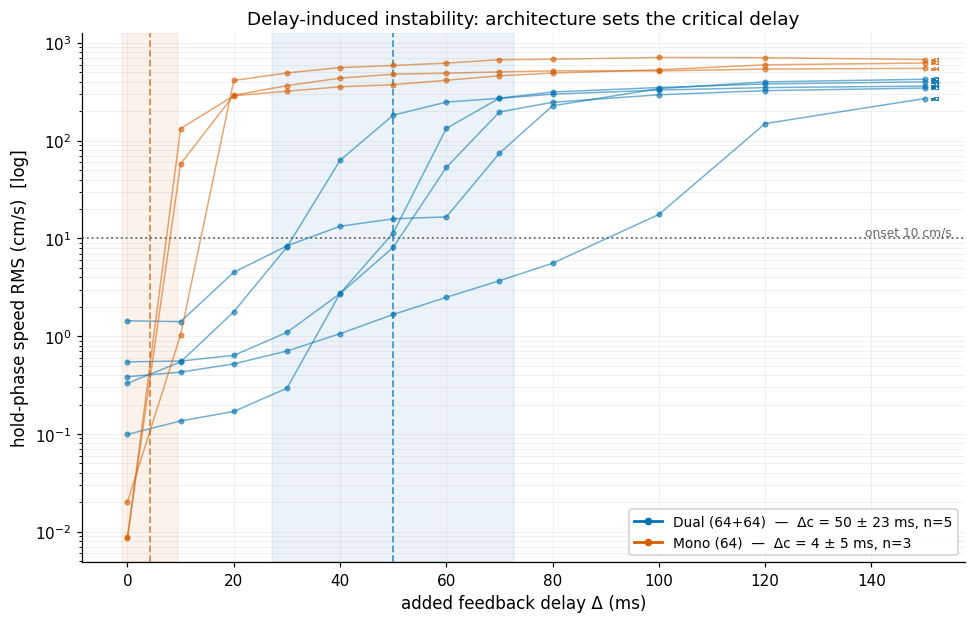

In [2]:
from evaluation.figures import delay_sweep_figure
from evaluation.sweep import load_delay_sweep_group

dual_sweeps = load_delay_sweep_group(cat.canonical("dual"), Paths(ROOT))
mono_sweeps = load_delay_sweep_group(cat.canonical("mono"), Paths(ROOT))
delay_sweep_figure({"Dual (64+64)": dual_sweeps, "Mono (64)": mono_sweeps}, Paths(ROOT))

Locked seed: 42
Locked seed: 42
Locked seed: 42
[fig] crescendo -> /Users/ana_radu/dissertation_clean/results/aggregated/tremor/R4_crescendo_dual_64+64u_s42.png


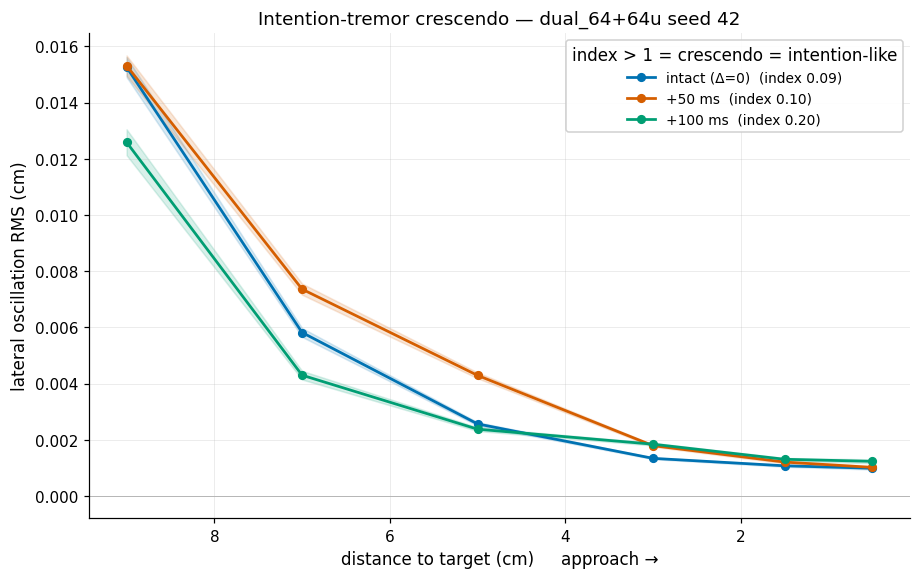

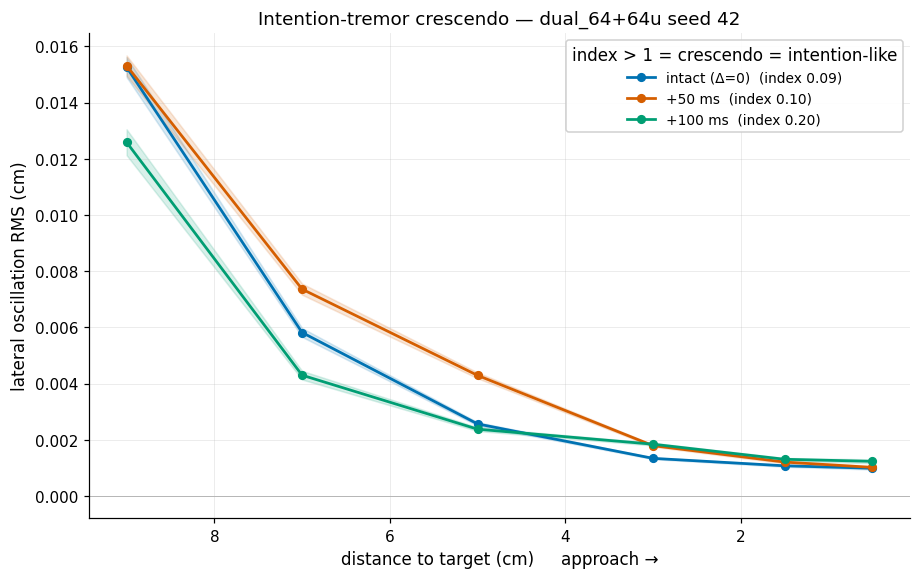

In [2]:
from evaluation.figures import crescendo_figure

crescendo_figure(cat.canonical("dual").record(42), Paths(ROOT), deltas_ms=(0, 50, 100))

Locked seed: 42


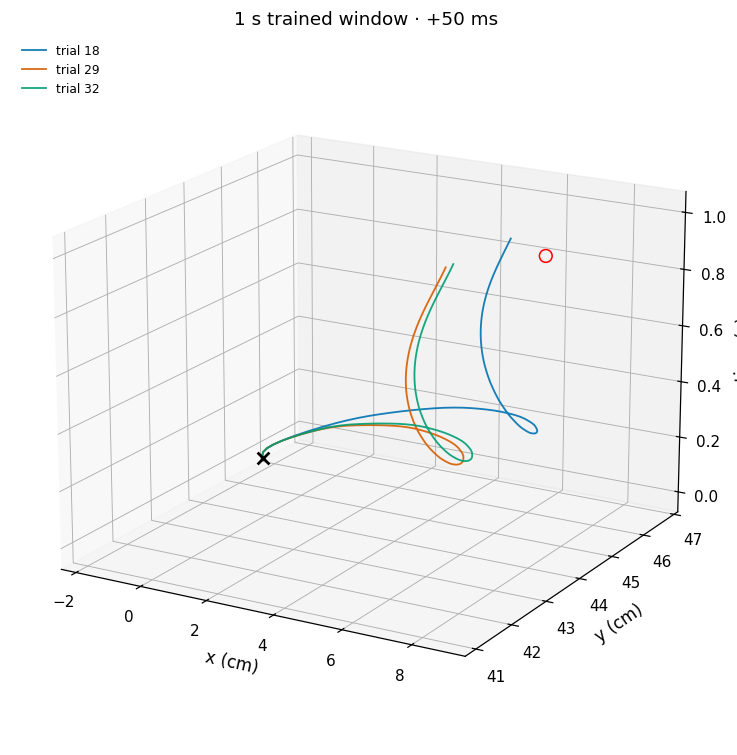

Locked seed: 42


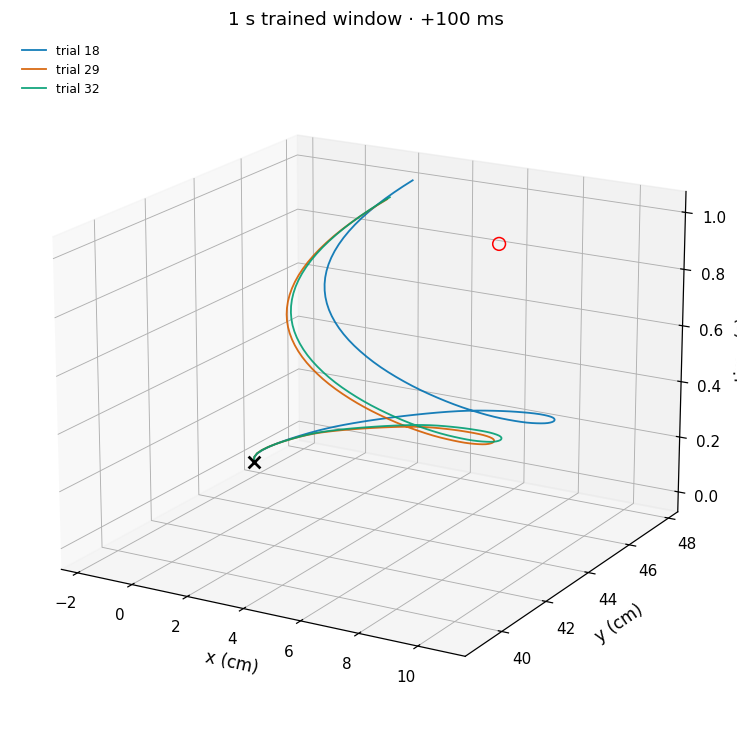

In [3]:
from evaluation.engine import rollout
from evaluation.manipulators.delay import delay
from evaluation.figures import plot_hold_trajectory_3d
import matplotlib.pyplot as plt

rec = cat.canonical("dual").record(42)
bp, bv = rec.config.proprioception_delay, rec.config.vision_delay
for d in (50, 100):
    iv = delay(d, mode="additive_both", base_prop_ms=bp, base_vision_ms=bv)
    res = rollout(rec, Paths(ROOT), task="reach", duration_s=1.0, batch_size=64, intervention=iv)
    fig = plot_hold_trajectory_3d(res, direction=0, n_trials=3, title=f"1 s trained window · +{d} ms")
    plt.show()

In [4]:
import numpy as np
from evaluation.engine import rollout
rec = cat.canonical("dual").record(42)
res = rollout(rec, Paths(ROOT), task="reach", duration_s=1.0, batch_size=64)
traj = np.asarray(res.trajectories); dt = res.dt
speed = np.linalg.norm(np.diff(traj, axis=0)/dt, axis=-1)   # [T,B] m/s
# time of peak speed and time hand first within 1cm, per trial, averaged
tgt = np.asarray(res.targets)
d = np.linalg.norm(traj - tgt[None], axis=-1)               # [T+1,B]
t_peak = speed.argmax(0)*dt
t_arrive = np.array([np.argmax(d[:,b]<0.01)*dt for b in range(d.shape[1])])
print(f"peak speed at {t_peak.mean()*1000:.0f} ms; within 1 cm at {t_arrive.mean()*1000:.0f} ms")

Locked seed: 42
peak speed at 103 ms; within 1 cm at 405 ms


Locked seed: 42
Locked seed: 42


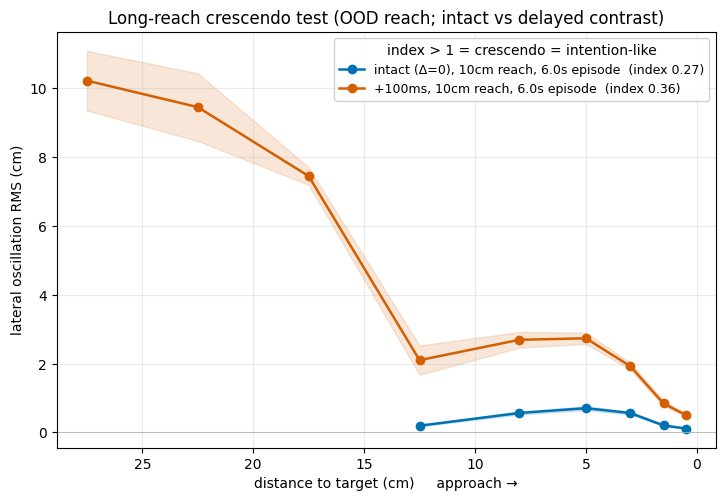

intact (Δ=0), 10cm reach, 6.0s episode index = 0.2690775609262456
+100ms, 10cm reach, 6.0s episode index = 0.3599587491660723
intact: min dist 0.2 cm, final dist 1.0 cm
+100ms: min dist 0.2 cm, final dist 2.7 cm


In [21]:
import dataclasses, numpy as np
from evaluation.engine import rollout
from evaluation.engine.types import IDENTITY
from evaluation.manipulators.delay import delay
from evaluation.analyzers.tremor import intention_tremor_profile
from evaluation.figures import plot_crescendo
import matplotlib.pyplot as plt

rec = cat.canonical("dual").record(42)
bp, bv = rec.config.proprioception_delay, rec.config.vision_delay

test_reach_distance = 0.1
test_episode_duration = 6.0

# Longer reach: 30 cm, 2 s episode (OOD, but the intact-vs-delayed CONTRAST controls for it)
def long_reach_rollout(intervention, dist_m=test_reach_distance, ep_s=test_episode_duration):
    # override reach_distance + duration on a config copy, then roll out
    cfg = dataclasses.replace(rec.config, reach_distance=dist_m, max_ep_duration=ep_s)
    # rollout() rebuilds env from record.config, so we need a record with the modified config:
    rec_long = dataclasses.replace(rec, config=cfg)
    return rollout(rec_long, Paths(ROOT), task="reach", duration_s=ep_s,
                   batch_size=64, intervention=intervention)

res_intact = long_reach_rollout(IDENTITY)
res_delay  = long_reach_rollout(delay(100, mode="additive_both", base_prop_ms=bp, base_vision_ms=bv))

# crescendo binned over the LONGER distance range (0..30 cm)
edges = (30, 25, 20, 15, 10, 6, 4, 2, 1, 0)
prof = {
    f"intact (Δ=0), {test_reach_distance*100:.0f}cm reach, {test_episode_duration}s episode": intention_tremor_profile(
        res_intact.trajectories, res_intact.targets, res_intact.dt,
        dist_edges_cm=edges, detrend="highpass"),
    f"+100ms, {test_reach_distance*100:.0f}cm reach, {test_episode_duration}s episode": intention_tremor_profile(
        res_delay.trajectories, res_delay.targets, res_delay.dt,
        dist_edges_cm=edges, detrend="highpass"),
}
fig = plot_crescendo(prof, title="Long-reach crescendo test (OOD reach; intact vs delayed contrast)")
plt.show()
for k,v in prof.items():
    print(k, "index =", float(np.nanmean(v["intention_index"])))
    
import numpy as np
for name, res in [("intact", res_intact), ("+100ms", res_delay)]:
    d = np.linalg.norm(np.asarray(res.trajectories) - np.asarray(res.targets)[None], axis=-1) * 100
    print(f"{name}: min dist {d.min(0).mean():.1f} cm, final dist {d[-1].mean():.1f} cm")

In [ ]:
# ============ IN-DISTRIBUTION DELAY SWEEP (R2/R4 defence) ============
# Measures Δc using ONLY in-distribution data: 1 s rollout (trained horizon), hold-RMS over the
# 0.6-1.0 s window (after the reach, still within training). If dual-vs-mono Δc separates HERE, the
# OOD-window objection is answered — the instability is a loop property visible in-distribution.

HOLD_LO, HOLD_HI = 0.6, 1.0        # in-distribution hold window (s), within the trained 1 s
GRID = (0, 10, 20, 30, 40, 50, 60, 70, 80, 100, 120, 150)
THRESHOLD = 10.0                    # cm/s onset (same as before)

def hold_rms_window(res, lo_s, hi_s):
    """Hold-phase speed RMS (cm/s) over [lo_s, hi_s] of THIS rollout, per trial -> mean."""
    traj = np.asarray(res.trajectories)
    speed = np.linalg.norm(np.diff(traj, axis=0)/res.dt, axis=-1) * 100.0   # [T,B] cm/s
    t = np.arange(speed.shape[0]) * res.dt
    m = (t >= lo_s) & (t < hi_s)
    if m.sum() == 0:
        return np.nan
    return float(np.sqrt((speed[m]**2).mean(0)).mean())   # RMS per trial, then mean over trials

def indist_sweep(rec):
    bp, bv = rec.config.proprioception_delay, rec.config.vision_delay
    xs, ys = [], []
    for d in GRID:
        iv = IDENTITY if d == 0 else delay(d, mode="additive_both", base_prop_ms=bp, base_vision_ms=bv)
        res = rollout(rec, paths, task="reach", duration_s=1.0, batch_size=128,
                      intervention=iv, seed=DEFAULT.rollout_seed)
        xs.append(d); ys.append(hold_rms_window(res, HOLD_LO, HOLD_HI))
    xs, ys = np.array(xs, float), np.array(ys, float)
    above = ys >= THRESHOLD
    if not above.any():
        dc = np.nan
    elif above.argmax() == 0:
        dc = 0.0
    else:
        i = above.argmax(); x0,x1,y0,y1 = xs[i-1],xs[i],ys[i-1],ys[i]
        dc = x0 + (THRESHOLD-y0)*(x1-x0)/(y1-y0)
    return xs, ys, dc

for arch in ("dual", "mono"):
    grp = cat.canonical(arch)
    dcs = []
    print(f"\n=== {arch} (in-distribution, hold {HOLD_LO}-{HOLD_HI}s of 1s rollout) ===")
    for rec in grp.records:
        xs, ys, dc = indist_sweep(rec)
        dcs.append(dc)
        print(f"  seed {rec.seed}: Δc = {dc:.0f} ms   (hold-RMS: " +
              " ".join(f"{y:.1f}" for y in ys) + ")")
    dcs = np.array(dcs, float); fin = dcs[np.isfinite(dcs)]
    if fin.size:
        print(f"  {arch} Δc = {np.nanmean(fin):.0f} ± {np.nanstd(fin, ddof=1):.0f} ms (n={fin.size})")
    else:
        print(f"  {arch}: never crosses threshold in-distribution")


=== dual (in-distribution, hold 0.6-1.0s of 1s rollout) ===
  seed 42: Δc = 54 ms   (hold-RMS: 1.7 2.1 3.1 4.7 6.4 8.8 11.9 16.2 21.7 34.3 48.6 69.4)
  seed 43: Δc = 40 ms   (hold-RMS: 0.8 1.4 2.8 5.4 9.8 16.4 25.7 37.7 52.6 85.7 111.3 136.0)
  seed 44: Δc = 30 ms   (hold-RMS: 0.7 1.5 4.4 10.1 19.9 43.9 63.3 92.1 115.9 160.4 215.4 317.1)
  seed 45: Δc = 24 ms   (hold-RMS: 1.5 2.2 7.0 14.8 24.6 31.8 39.5 53.3 70.6 140.1 193.4 255.7)
  seed 46: Δc = 41 ms   (hold-RMS: 0.7 1.2 1.8 3.2 8.7 21.6 43.3 69.8 98.8 142.8 188.1 298.9)
  dual Δc = 38 ± 12 ms (n=5)

=== mono (in-distribution, hold 0.6-1.0s of 1s rollout) ===
  seed 42: Δc = 1 ms   (hold-RMS: 0.2 82.8 257.3 363.6 418.6 500.8 487.9 478.0 486.0 581.6 604.9 535.0)
  seed 43: Δc = 6 ms   (hold-RMS: 0.2 15.4 340.4 452.4 555.6 535.8 527.4 607.1 550.0 557.3 616.2 522.9)
  seed 44: Δc = 2 ms   (hold-RMS: 0.2 58.9 271.6 319.6 391.6 449.8 490.8 498.2 540.0 535.3 528.6 516.7)
  mono Δc = 3 ± 3 ms (n=3)


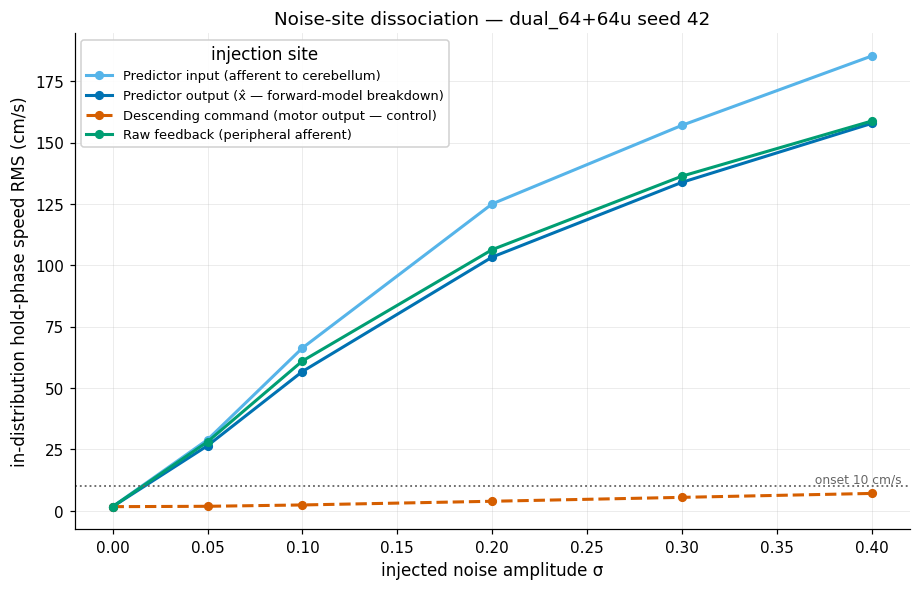

predictor_input   :    1.7   29.0   66.4  125.1  157.1  185.4
predictor_output  :    1.7   26.5   56.8  103.4  133.9  157.9
command           :    1.7    1.8    2.4    3.9    5.5    7.1
feedback          :    1.7   28.1   61.1  106.4  136.4  158.9


In [6]:
import matplotlib.pyplot as plt

from evaluation.figures import apply_style, save_figure
from evaluation.figures.noise_dissociation import plot_noise_dissociation
from evaluation.noise_sweep import noise_sweep

apply_style()

rec = cat.canonical("dual").record(42)
sweeps = noise_sweep(rec, paths)          # all 4 sites, in-distribution
fig = plot_noise_dissociation(sweeps, title=f"Noise-site dissociation — {rec.label} seed {rec.seed}")
save_figure(fig, paths.aggregated_dir("noise", create=True) / "F8_noise_dissociation", formats=("png",), close=False)

plt.show()

for sw in sweeps:
    print(f"{sw.site:18s}: " + " ".join(f"{y:6.1f}" for y in sw.hold_rms_cms))

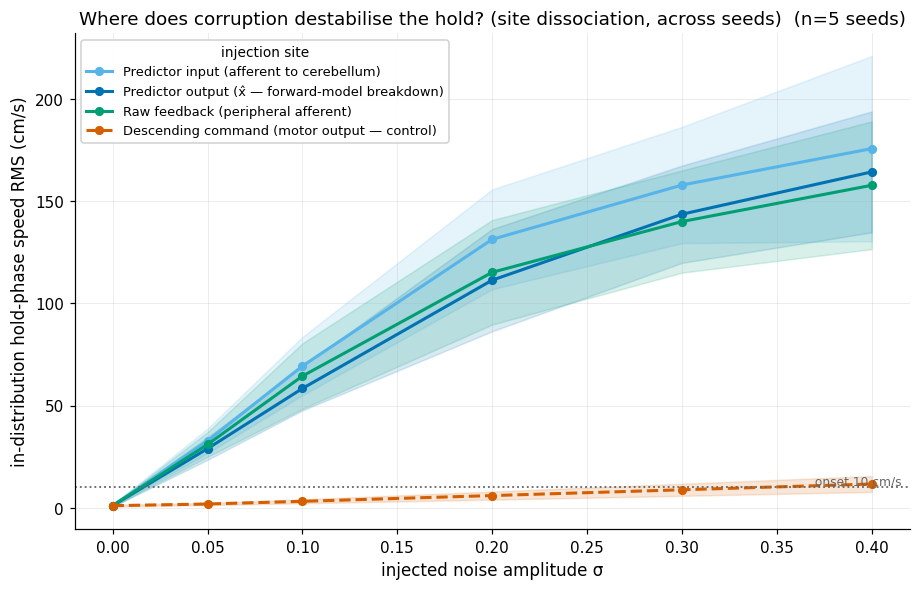

site               σ=0 σ=0.05 σ=0.1 σ=0.2 σ=0.3 σ=0.4
predictor_input        1±  0    33±  6    69± 14   131± 24   158± 28   176± 45
predictor_output       1±  0    29±  5    58± 11   111± 25   144± 24   164± 30
feedback               1±  0    31±  6    64± 16   115± 26   140± 25   158± 31
command                1±  0     2±  0     3±  1     6±  2     9±  3    12±  4


In [3]:
from matplotlib import pyplot as plt

from evaluation.figures import apply_style, save_figure
from evaluation.figures.noise_dissociation import plot_noise_dissociation_grouped
from evaluation.noise_sweep import noise_sweep_group

apply_style()

grp = cat.canonical("dual")
agg = noise_sweep_group(grp, paths)
fig = plot_noise_dissociation_grouped(agg, n_seeds=grp.n_seeds)
save_figure(fig, paths.aggregated_dir("noise", create=True) / "F8_noise_dissociation_multiseed",
            formats=("png",), close=False)
plt.show()

# the numbers for the chapter text: command vs estimation at the top sigma
print(f"{'site':18s} " + " ".join(f"σ={s:g}" for s in agg['command']['sigma']))
for site in ["predictor_input","predictor_output","feedback","command"]:
    if site in agg:
        print(f"{site:18s} " + " ".join(f"{m:5.0f}±{sd:3.0f}" for m,sd in zip(agg[site]['mean'], np.nan_to_num(agg[site]['sd']))))

In [ ]:
from evaluation.figures.signature_matrix import plot_signature_matrix
from evaluation.signature_matrix import (
    aggregate_signatures,
    hypothesis_signature_matrix,
)

df = hypothesis_signature_matrix(cat, paths, delta_ms=60.0, sigma=0.3)
text_df, num_df = aggregate_signatures(df)
print(text_df)                                    # the table for your chapter
fig = plot_signature_matrix(text_df, num_df)
save_figure(fig, paths.aggregated_dir("signatures", create=True) / "F9_hypothesis_matrix",
            formats=("png",), close=False)
plt.show()